### joint-RPCA

In [ ]:
biom convert \
 -i jrpca_16sbdm_feattab.txt \
 -o jrpca_16sbdm_feattab.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path jrpca_16sbdm_feattab.biom \
 --output-path jrpca_16sbdm_feattab.qza \
 --type FeatureTable[Frequency]

biom convert \
 -i jrpca_mtbBA_feattab.txt \
 -o jrpca_mtbBA_feattab.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path jrpca_mtbBA_feattab.biom \
 --output-path jrpca_mtbBA_feattab.qza \
 --type FeatureTable[Frequency]

In [ ]:
qiime gemelli joint-rpca \
    --i-tables jrpca_16sbdm_feattab.qza jrpca_mtbBA_feattab.qza \
    --m-sample-metadata-file /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/jrpca_metadata.txt \
    --p-train-test-column  'traintest' \
    --p-max-iterations 25 \
    --p-min-feature-frequency 5 \
    --o-biplot /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/joint_biplot.qza\
    --o-distance-matrix /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/joint_distance_matrix.qza\
    --o-cross-validation-error /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/cross_validation_error.qza

In [ ]:
qiime emperor biplot \
    --i-biplot /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/joint_biplot.qza \
    --m-sample-metadata-file /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/jrpca_metadata.txt \
    --p-number-of-features 25 \
    --o-visualization /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/emperor-biplot.qzv

In [ ]:
qiime gemelli feature-correlation-table \
    --i-ordination /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/joint_biplot.qza \
    --o-correlation-table /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/correlation_table.qza

qiime tools export --input-path /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/correlation_table.qza \
--output-path /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/correlation_table

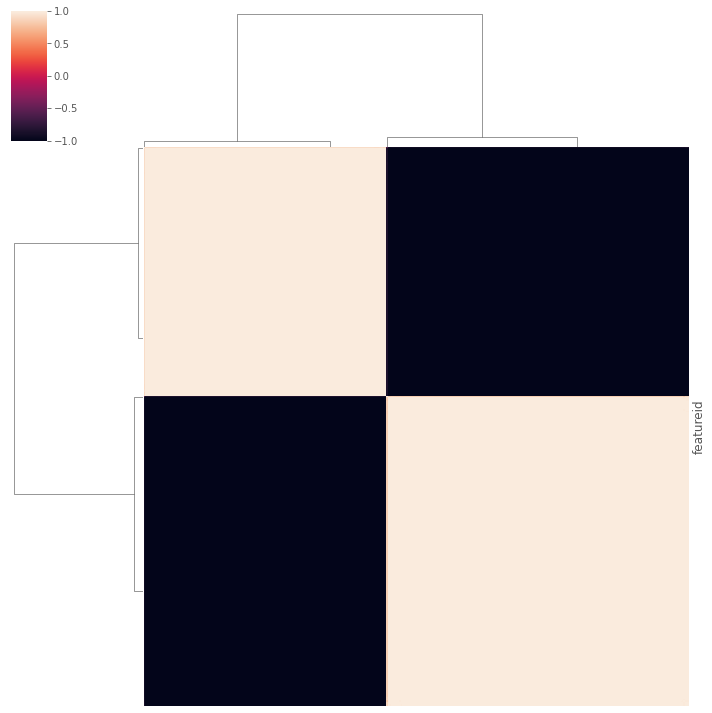

In [9]:
# import data utils
import pandas as pd
import qiime2 as q2
# plotting
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline

# export the correlations (Note: this step can take a few minutes)
correlation_table = pd.read_table('/mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/correlation_table/Correlation.tsv', sep='\t', index_col=0)

# plot the correlations (Note: this step can take a few minutes)
sns.clustermap(correlation_table,yticklabels=False,
               xticklabels=False)

#plt.show()
plt.savefig('/mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA/correlation_table/Correlation_heatmap.png',
            dpi=300,bbox_inches='tight')

In [ ]:
biom convert \
 -i jrpca_16sbdm_shared_feattab.txt \
 -o jrpca_16sbdm_shared_feattab.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path jrpca_16sbdm_shared_feattab.biom \
 --output-path jrpca_16sbdm_shared_feattab.qza \
 --type FeatureTable[Frequency]

biom convert \
 -i jrpca_mtbBA_feattab.txt \
 -o jrpca_mtbBA_feattab.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path jrpca_mtbBA_feattab.biom \
 --output-path jrpca_mtbBA_feattab.qza \
 --type FeatureTable[Frequency]

In [ ]:
qiime gemelli joint-rpca \
    --i-tables jrpca_16sbdm_shared_feattab.qza jrpca_mtbBA_feattab.qza \
    --m-sample-metadata-file /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/jrpca_metadata.txt \
    --p-train-test-column  'traintest' \
    --p-max-iterations 25 \
    --p-min-feature-frequency 5 \
    --o-biplot /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/joint_biplot.qza\
    --o-distance-matrix /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/joint_distance_matrix.qza\
    --o-cross-validation-error /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/cross_validation_error.qza

In [ ]:
qiime emperor biplot \
    --i-biplot /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/joint_biplot.qza \
    --m-sample-metadata-file /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/jrpca_metadata.txt \
    --p-number-of-features 25 \
    --o-visualization /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/emperor-biplot.qzv

In [ ]:
qiime gemelli feature-correlation-table \
    --i-ordination /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/joint_biplot.qza \
    --o-correlation-table /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/correlation_table.qza

qiime tools export --input-path /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/correlation_table.qza \
--output-path /mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/correlation_table

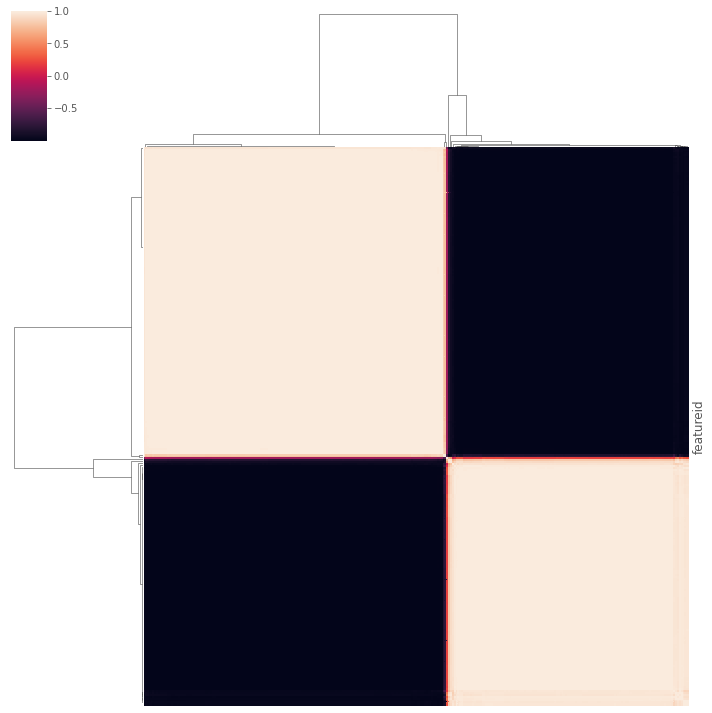

In [11]:
# import data utils
import pandas as pd
import qiime2 as q2
# plotting
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline

# export the correlations (Note: this step can take a few minutes)
correlation_table = pd.read_table('/mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/correlation_table/Correlation.tsv', sep='\t', index_col=0)

# plot the correlations (Note: this step can take a few minutes)
sns.clustermap(correlation_table,yticklabels=False,
               xticklabels=False)

#plt.show()
plt.savefig('/mnt/zarrinpar/scratch/sfloresr/NASH_KF/multiomics_16smtb/result_bdmBA_sel/correlation_table/Correlation_heatmap.png',
            dpi=300,bbox_inches='tight')

## Selecting the microbes (10) and metabolites (41) that were different & shared b/w wk8 and wk12 using Birdman (wk12 quant tables)

In [ ]:
biom convert \
 -i /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_gg2.txt \
 -o /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_gg2.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_gg2.biom \
 --output-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_gg2.qza \
 --type FeatureTable[Frequency]

biom convert \
 -i /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab.txt \
 -o /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab.biom \
 --output-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab.qza \
 --type FeatureTable[Frequency]

In [ ]:
qiime gemelli joint-rpca \
    --i-tables /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_gg2.qza /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab.qza \
    --m-sample-metadata-file /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_metadata.txt \
    --p-train-test-column  'traintest' \
    --p-max-iterations 25 \
    --p-min-feature-frequency 5 \
    --o-biplot /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/joint_biplot.qza\
    --o-distance-matrix /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/joint_distance_matrix.qza\
    --o-cross-validation-error /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/cross_validation_error.qza

In [ ]:
qiime emperor biplot \
    --i-biplot /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/joint_biplot.qza \
    --m-sample-metadata-file /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_metadata.txt \
    --p-number-of-features 25 \
    --o-visualization /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/emperor-biplot.qzv

In [ ]:
qiime gemelli feature-correlation-table \
    --i-ordination /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/joint_biplot.qza \
    --o-correlation-table /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/correlation_table.qza

qiime tools export --input-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/correlation_table.qza \
--output-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_gg2/correlation_table

## Selecting the microbes (10) and metabolites (41) that were different & shared b/w wk8 and wk12 using Birdman (wk8 quant tables)

In [ ]:
biom convert \
 -i /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_wk8_gg2.txt \
 -o /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_wk8_gg2.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_wk8_gg2.biom \
 --output-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_wk8_gg2.qza \
 --type FeatureTable[Frequency]

biom convert \
 -i /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab_wk8.txt \
 -o /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab_wk8.biom \
 --table-type="OTU table" \
 --to-hdf5

qiime tools import \
 --input-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab_wk8.biom \
 --output-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab_wk8.qza \
 --type FeatureTable[Frequency]

In [ ]:
qiime gemelli joint-rpca \
    --i-tables /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_16sbdm_shared_feattab_wk8_gg2.qza /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_mtbbdm_sel41_feattab_wk8.qza \
    --m-sample-metadata-file /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_metadata_wk8.txt \
    --p-train-test-column  'traintest' \
    --p-max-iterations 25 \
    --p-min-feature-frequency 5 \
    --o-biplot /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/joint_biplot.qza\
    --o-distance-matrix /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/joint_distance_matrix.qza\
    --o-cross-validation-error /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/cross_validation_error.qza

In [ ]:
qiime emperor biplot \
    --i-biplot /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/joint_biplot.qza \
    --m-sample-metadata-file /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/data/multiomics/jrpca_metadata_wk8.txt \
    --p-number-of-features 25 \
    --o-visualization /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/emperor-biplot.qzv

In [ ]:
qiime gemelli feature-correlation-table \
    --i-ordination /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/joint_biplot.qza \
    --o-correlation-table /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/correlation_table.qza

qiime tools export --input-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/correlation_table.qza \
--output-path /mnt/zarrinpar/Pynchon/Notebooks/sfloresr/MASH-TRF/MASHomics/results/multiomics/result_bdm_sel41mtb_sel10micro_wk8_gg2/correlation_table